In [1]:
from pathlib import Path
import requests
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
CARPETA_REPORTES = Path("dia_16_reportes_api")
CARPETA_CSV = CARPETA_REPORTES / "csv"
CARPETA_GRAFICAS = CARPETA_REPORTES / "graficas"

CARPETA_CSV.mkdir(parents=True, exist_ok=True)
CARPETA_GRAFICAS.mkdir(parents=True, exist_ok=True)

print("Carpeta de reportes:")
print(CARPETA_REPORTES.resolve())

print("\nCarpeta CSV:")
print(CARPETA_CSV.resolve())

print("\nCarpeta gráficas:")
print(CARPETA_GRAFICAS.resolve())

Carpeta de reportes:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api

Carpeta CSV:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv

Carpeta gráficas:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\graficas


In [3]:
class ClienteAPI:
    """
    Cliente para consumir la API del sistema de ventas.

    Esta clase guarda:
    - La URL base de la API.
    - Una sesión de requests.
    - Métodos para consultar productos, clientes, ventas y tickets.
    """

    def __init__(self, base_url):
        self.base_url = base_url.rstrip("/")
        self.session = requests.Session()

    def hacer_peticion(self, metodo, ruta, json_data=None, params=None):
        """
        Ejecuta una petición HTTP a la API.
        """
        url = f"{self.base_url}{ruta}"

        try:
            respuesta = self.session.request(
                method=metodo,
                url=url,
                json=json_data,
                params=params,
                timeout=5
            )

            return respuesta

        except requests.exceptions.ConnectionError:
            print("No se pudo conectar con la API.")
            print("Verifica que el servidor esté encendido.")
            return None

        except requests.exceptions.Timeout:
            print("La API tardó demasiado en responder.")
            return None

        except requests.exceptions.RequestException as error:
            print("Error inesperado al consumir la API.")
            print("Detalle:", error)
            return None

    def obtener_json(self, respuesta):
        """
        Convierte una respuesta HTTP en JSON.
        """
        if respuesta is None:
            return None

        try:
            return respuesta.json()

        except Exception:
            print("La respuesta no contiene JSON válido.")
            return None

    def validar_respuesta(self, respuesta):
        """
        Valida si la respuesta fue exitosa.

        Si fue correcta, devuelve el JSON.
        Si hubo error, muestra el detalle.
        """
        if respuesta is None:
            return None

        if 200 <= respuesta.status_code < 300:
            return self.obtener_json(respuesta)

        contenido = self.obtener_json(respuesta)

        print("Error HTTP:", respuesta.status_code)

        if isinstance(contenido, dict):
            print("Detalle:", contenido.get("detail", contenido))
        else:
            print("Detalle:", contenido)

        return None

    def health(self):
        respuesta = self.hacer_peticion("GET", "/health")
        return self.validar_respuesta(respuesta)

    def listar_productos(self, solo_activos=True):
        respuesta = self.hacer_peticion(
            "GET",
            "/productos",
            params={"solo_activos": solo_activos}
        )

        return self.validar_respuesta(respuesta)

    def buscar_producto(self, sku):
        respuesta = self.hacer_peticion("GET", f"/productos/{sku}")
        return self.validar_respuesta(respuesta)

    def listar_clientes(self, solo_activos=True):
        respuesta = self.hacer_peticion(
            "GET",
            "/clientes",
            params={"solo_activos": solo_activos}
        )

        return self.validar_respuesta(respuesta)

    def listar_ventas(self):
        respuesta = self.hacer_peticion("GET", "/ventas")
        return self.validar_respuesta(respuesta)

    def consultar_ticket(self, id_venta):
        respuesta = self.hacer_peticion("GET", f"/ventas/{id_venta}/ticket")
        return self.validar_respuesta(respuesta)

    def resumen_ventas(self):
        respuesta = self.hacer_peticion("GET", "/ventas/resumen")
        return self.validar_respuesta(respuesta)

In [44]:
api = ClienteAPI("http://127.0.0.1:8000")

api.health()

No se pudo conectar con la API.
Verifica que el servidor esté encendido.


In [ ]:
productos_json = api.listar_productos(solo_activos=False)

productos_json

No se pudo conectar con la API.
Verifica que el servidor esté encendido.


In [46]:
productos_df = pd.DataFrame(productos_json)

productos_df

""


In [7]:
clientes_json = api.listar_clientes(solo_activos=False)

clientes_df = pd.DataFrame(clientes_json)

clientes_df

,id_cliente,nombre,correo,telefono,ciudad,activo
0,1,Ana López,ana@example.com,555-111-2222,CDMX,1
1,2,Carlos Pérez,carlos@example.com,555-333-4444,Guadalajara,1
2,4,Luis Romero,luis@example.com,555-888-9999,Puebla,1
3,3,María Torres,maria@example.com,NaN,Monterrey,1
4,5,Sofía Herrera,sofia@example.com,NaN,Querétaro,1


In [8]:
ventas_json = api.listar_ventas()

ventas_df = pd.DataFrame(ventas_json)

ventas_df

,id_venta,fecha,estado,cliente,total
0,4,2026-06-26 16:03:40,ACTIVA,Ana López,3299.0
1,3,2026-06-26 16:02:02,ACTIVA,Ana López,1398.8
2,2,2026-06-26 16:01:46,ACTIVA,Ana López,1398.8
3,1,2026-06-25 18:48:23,ACTIVA,Ana López,1398.8


In [9]:
def construir_reporte_ventas_detalle(api, ventas_df):
    """
    Construye un DataFrame con el detalle completo de todas las ventas.

    Usa la API para consultar el ticket de cada venta.
    """
    tickets = []

    if ventas_df.empty:
        return pd.DataFrame()

    for id_venta in ventas_df["id_venta"]:
        ticket = api.consultar_ticket(id_venta)

        if ticket:
            tickets.extend(ticket)

    reporte = pd.DataFrame(tickets)

    return reporte

In [10]:
ventas_detalle_df = construir_reporte_ventas_detalle(api, ventas_df)

ventas_detalle_df

,id_venta,fecha,estado,cliente,correo,sku,producto,cantidad,precio_unitario,subtotal,total_venta
0,4,2026-06-26 16:03:40,ACTIVA,Ana López,ana@example.com,P003,Monitor 24 pulgadas,1,3299.0,3299.0,3299.0
1,3,2026-06-26 16:02:02,ACTIVA,Ana López,ana@example.com,P001,Mouse inalámbrico,2,249.9,499.8,1398.8
2,3,2026-06-26 16:02:02,ACTIVA,Ana López,ana@example.com,P002,Teclado mecánico,1,899.0,899.0,1398.8
3,2,2026-06-26 16:01:46,ACTIVA,Ana López,ana@example.com,P001,Mouse inalámbrico,2,249.9,499.8,1398.8
4,2,2026-06-26 16:01:46,ACTIVA,Ana López,ana@example.com,P002,Teclado mecánico,1,899.0,899.0,1398.8
5,1,2026-06-25 18:48:23,ACTIVA,Ana López,ana@example.com,P001,Mouse inalámbrico,2,249.9,499.8,1398.8
6,1,2026-06-25 18:48:23,ACTIVA,Ana López,ana@example.com,P002,Teclado mecánico,1,899.0,899.0,1398.8


In [11]:
print("Productos:")
print(productos_df.columns.tolist())

print("\nClientes:")
print(clientes_df.columns.tolist())

print("\nVentas:")
print(ventas_df.columns.tolist())

print("\nDetalle:")
print(ventas_detalle_df.columns.tolist())

Productos:
['id_producto', 'sku', 'nombre', 'categoria', 'precio', 'stock', 'activo']

Clientes:
['id_cliente', 'nombre', 'correo', 'telefono', 'ciudad', 'activo']

Ventas:
['id_venta', 'fecha', 'estado', 'cliente', 'total']

Detalle:
['id_venta', 'fecha', 'estado', 'cliente', 'correo', 'sku', 'producto', 'cantidad', 'precio_unitario', 'subtotal', 'total_venta']


In [12]:
if not productos_df.empty:
    productos_df["precio"] = pd.to_numeric(productos_df["precio"], errors="coerce")
    productos_df["stock"] = pd.to_numeric(productos_df["stock"], errors="coerce")
    productos_df["activo"] = pd.to_numeric(productos_df["activo"], errors="coerce")

if not ventas_df.empty:
    ventas_df["total"] = pd.to_numeric(ventas_df["total"], errors="coerce")

if not ventas_detalle_df.empty:
    ventas_detalle_df["cantidad"] = pd.to_numeric(ventas_detalle_df["cantidad"], errors="coerce")
    ventas_detalle_df["precio_unitario"] = pd.to_numeric(ventas_detalle_df["precio_unitario"], errors="coerce")
    ventas_detalle_df["subtotal"] = pd.to_numeric(ventas_detalle_df["subtotal"], errors="coerce")
    ventas_detalle_df["total_venta"] = pd.to_numeric(ventas_detalle_df["total_venta"], errors="coerce")

In [13]:
def exportar_csv(df, nombre_archivo):
    """
    Exporta un DataFrame a CSV dentro de la carpeta de reportes.
    """
    ruta = CARPETA_CSV / nombre_archivo

    df.to_csv(ruta, index=False, encoding="utf-8-sig")

    print("CSV exportado:")
    print(ruta.resolve())

    return ruta

In [14]:
exportar_csv(productos_df, "productos_api.csv")
exportar_csv(clientes_df, "clientes_api.csv")
exportar_csv(ventas_df, "ventas_api.csv")
exportar_csv(ventas_detalle_df, "ventas_detalle_api.csv")

CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\productos_api.csv
CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\clientes_api.csv
CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\ventas_api.csv
CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\ventas_detalle_api.csv


WindowsPath('dia_16_reportes_api/csv/ventas_detalle_api.csv')

In [15]:
def generar_ventas_por_producto(ventas_detalle_df):
    """
    Genera reporte de unidades vendidas e importe por producto.
    """
    if ventas_detalle_df.empty:
        return pd.DataFrame()

    ventas_activas = ventas_detalle_df[
        ventas_detalle_df["estado"] == "ACTIVA"
    ].copy()

    reporte = (
        ventas_activas
        .groupby(["sku", "producto"], as_index=False)
        .agg(
            unidades_vendidas=("cantidad", "sum"),
            importe_total=("subtotal", "sum")
        )
        .sort_values("importe_total", ascending=False)
    )

    return reporte

In [16]:
ventas_por_producto_df = generar_ventas_por_producto(ventas_detalle_df)

ventas_por_producto_df

,sku,producto,unidades_vendidas,importe_total
2,P003,Monitor 24 pulgadas,1,3299.0
1,P002,Teclado mecánico,3,2697.0
0,P001,Mouse inalámbrico,6,1499.4


In [17]:
exportar_csv(ventas_por_producto_df, "ventas_por_producto_api.csv")

CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\ventas_por_producto_api.csv


WindowsPath('dia_16_reportes_api/csv/ventas_por_producto_api.csv')

In [18]:
def generar_ventas_por_cliente(ventas_df):
    """
    Genera reporte de ventas agrupadas por cliente.
    """
    if ventas_df.empty:
        return pd.DataFrame()

    ventas_activas = ventas_df[
        ventas_df["estado"] == "ACTIVA"
    ].copy()

    reporte = (
        ventas_activas
        .groupby("cliente", as_index=False)
        .agg(
            cantidad_ventas=("id_venta", "count"),
            total_comprado=("total", "sum")
        )
        .sort_values("total_comprado", ascending=False)
    )

    return reporte

In [19]:
ventas_por_cliente_df = generar_ventas_por_cliente(ventas_df)

ventas_por_cliente_df

,cliente,cantidad_ventas,total_comprado
0,Ana López,4,7495.4


In [20]:
exportar_csv(ventas_por_cliente_df, "ventas_por_cliente_api.csv")

CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\ventas_por_cliente_api.csv


WindowsPath('dia_16_reportes_api/csv/ventas_por_cliente_api.csv')

In [21]:
def generar_productos_bajo_stock(productos_df, umbral=5):
    """
    Genera reporte de productos activos con bajo stock.
    """
    if productos_df.empty:
        return pd.DataFrame()

    reporte = productos_df[
        (productos_df["activo"] == 1) &
        (productos_df["stock"] <= umbral)
    ].copy()

    reporte = reporte.sort_values("stock", ascending=True)

    return reporte

In [22]:
productos_bajo_stock_df = generar_productos_bajo_stock(productos_df, umbral=5)

productos_bajo_stock_df

,id_producto,sku,nombre,categoria,precio,stock,activo
3,3,P003,Monitor 24 pulgadas,Pantallas,3299.0,3,1
5,2,P002,Teclado mecánico,Accesorios,899.0,5,1


In [23]:
exportar_csv(productos_bajo_stock_df, "productos_bajo_stock_api.csv")

CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\productos_bajo_stock_api.csv


WindowsPath('dia_16_reportes_api/csv/productos_bajo_stock_api.csv')

In [24]:
def generar_valor_inventario(productos_df):
    """
    Calcula el valor de inventario por producto.
    """
    if productos_df.empty:
        return pd.DataFrame()

    activos = productos_df[
        productos_df["activo"] == 1
    ].copy()

    activos["valor_inventario"] = activos["precio"] * activos["stock"]

    reporte = activos[
        [
            "sku",
            "nombre",
            "categoria",
            "precio",
            "stock",
            "valor_inventario"
        ]
    ].sort_values("valor_inventario", ascending=False)

    return reporte

In [25]:
valor_inventario_df = generar_valor_inventario(productos_df)

valor_inventario_df

,sku,nombre,categoria,precio,stock,valor_inventario
3,P003,Monitor 24 pulgadas,Pantallas,3299.0,3,9897.0
0,P006,Bocinas Bluetooth,Audio,699.0,10,6990.0
2,P005,Memoria USB 64GB,Almacenamiento,150.0,30,4500.0
5,P002,Teclado mecánico,Accesorios,899.0,5,4495.0
1,P004,Cable HDMI,Cables,120.0,20,2400.0
4,P001,Mouse inalámbrico,Accesorios,249.9,9,2249.1


In [26]:
exportar_csv(valor_inventario_df, "valor_inventario_api.csv")

CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\valor_inventario_api.csv


WindowsPath('dia_16_reportes_api/csv/valor_inventario_api.csv')

In [27]:
def generar_resumen_general(productos_df, clientes_df, ventas_df):
    """
    Genera un resumen general del negocio usando datos obtenidos desde la API.
    """
    productos_activos = productos_df[productos_df["activo"] == 1]
    clientes_activos = clientes_df[clientes_df["activo"] == 1]
    ventas_activas = ventas_df[ventas_df["estado"] == "ACTIVA"]

    valor_inventario = (
        productos_activos["precio"] * productos_activos["stock"]
    ).sum()

    resumen = {
        "productos_activos": len(productos_activos),
        "clientes_activos": len(clientes_activos),
        "ventas_activas": len(ventas_activas),
        "ingresos_totales": ventas_activas["total"].sum(),
        "valor_inventario": valor_inventario
    }

    return pd.DataFrame([resumen])

In [28]:
resumen_general_df = generar_resumen_general(
    productos_df,
    clientes_df,
    ventas_df
)

resumen_general_df

,productos_activos,clientes_activos,ventas_activas,ingresos_totales,valor_inventario
0,6,5,4,7495.4,30531.1


In [29]:
exportar_csv(resumen_general_df, "resumen_general_api.csv")

CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\resumen_general_api.csv


WindowsPath('dia_16_reportes_api/csv/resumen_general_api.csv')

In [ ]:
def graficar_ventas_por_producto(df):
    if df.empty:
        print("No hay datos para graficar ventas por producto.")
        return None

    plt.figure(figsize=(10, 5))
    plt.bar(df["producto"], df["importe_total"])
    plt.title("Ventas por producto")
    plt.xlabel("Producto")
    plt.ylabel("Importe total vendido")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    ruta = CARPETA_GRAFICAS / "ventas_por_producto_api.png"
    plt.savefig(ruta, dpi=150)
    plt.show()

    print("Gráfica guardada:")
    print(ruta.resolve())

    return ruta

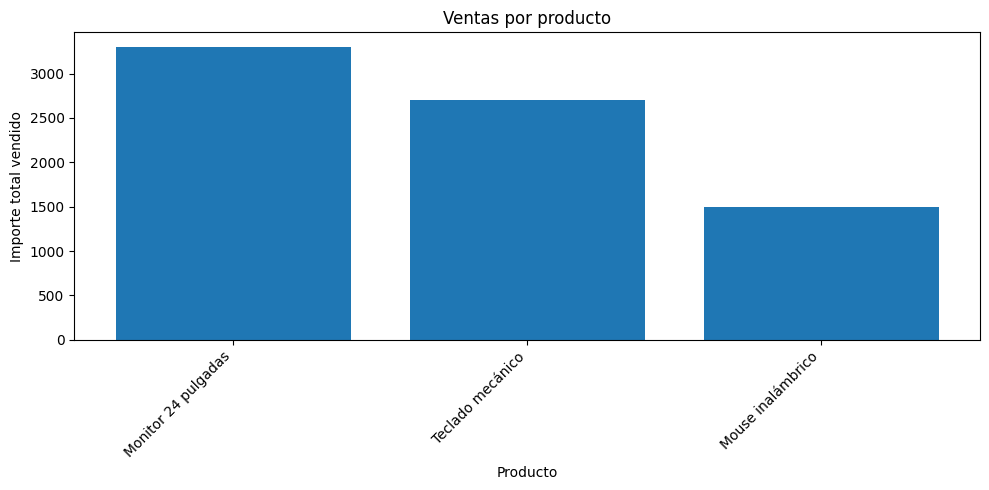

Gráfica guardada:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\graficas\ventas_por_producto_api.png


WindowsPath('dia_16_reportes_api/graficas/ventas_por_producto_api.png')

In [31]:
graficar_ventas_por_producto(ventas_por_producto_df)

In [33]:
def graficar_ventas_por_cliente(df):
    if df.empty:
        print("No hay datos para graficar ventas por cliente.")
        return None

    plt.figure(figsize=(10, 5))
    plt.bar(df["cliente"], df["total_comprado"])
    plt.title("Ventas por cliente")
    plt.xlabel("Cliente")
    plt.ylabel("Total comprado")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    ruta = CARPETA_GRAFICAS / "ventas_por_cliente_api.png"
    plt.savefig(ruta, dpi=150)
    plt.show()

    print("Gráfica guardada:")
    print(ruta.resolve())

    return ruta

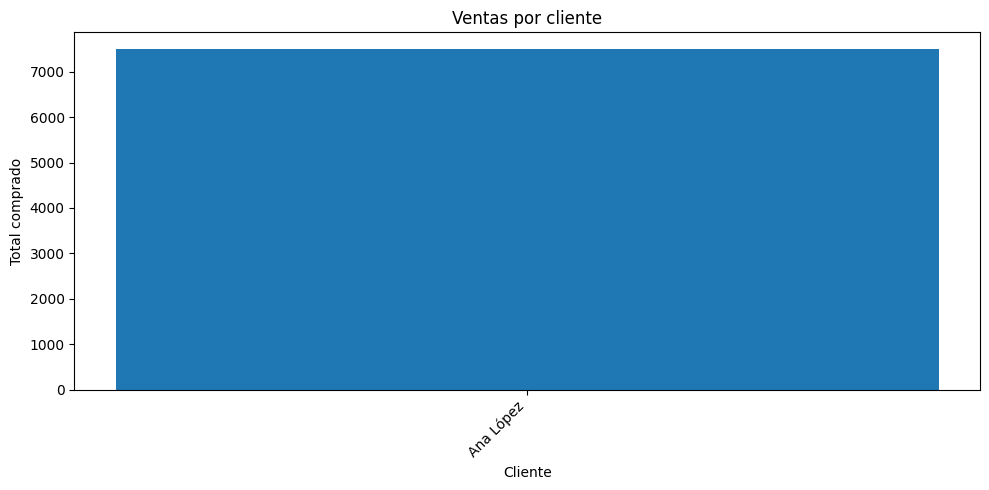

Gráfica guardada:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\graficas\ventas_por_cliente_api.png


WindowsPath('dia_16_reportes_api/graficas/ventas_por_cliente_api.png')

In [34]:
graficar_ventas_por_cliente(ventas_por_cliente_df)

In [35]:
def graficar_productos_bajo_stock(df):
    if df.empty:
        print("No hay productos con bajo stock para graficar.")
        return None

    plt.figure(figsize=(10, 5))
    plt.bar(df["nombre"], df["stock"])
    plt.title("Productos con bajo stock")
    plt.xlabel("Producto")
    plt.ylabel("Stock actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    ruta = CARPETA_GRAFICAS / "productos_bajo_stock_api.png"
    plt.savefig(ruta, dpi=150)
    plt.show()

    print("Gráfica guardada:")
    print(ruta.resolve())

    return ruta

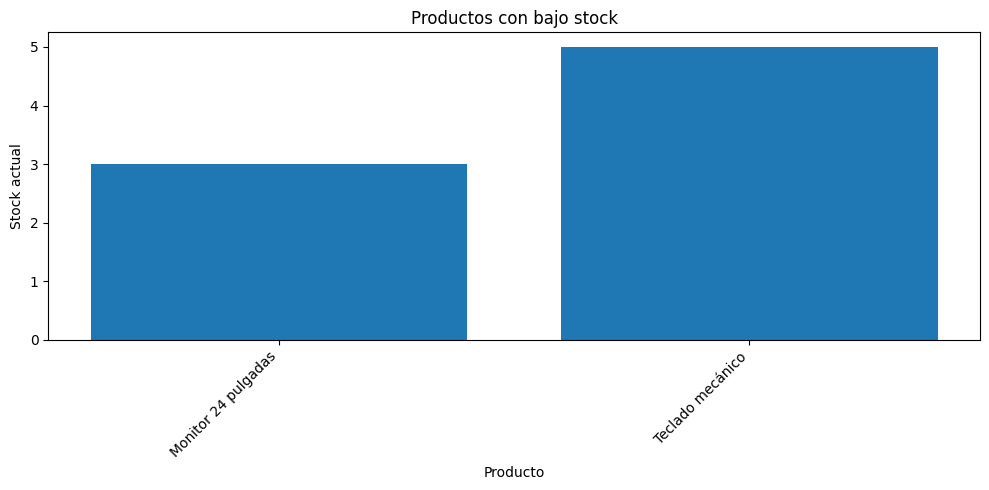

Gráfica guardada:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\graficas\productos_bajo_stock_api.png


WindowsPath('dia_16_reportes_api/graficas/productos_bajo_stock_api.png')

In [36]:
graficar_productos_bajo_stock(productos_bajo_stock_df)

In [37]:
def graficar_valor_inventario_por_categoria(valor_inventario_df):
    if valor_inventario_df.empty:
        print("No hay datos de inventario para graficar.")
        return None

    datos = (
        valor_inventario_df
        .groupby("categoria", as_index=False)
        .agg(valor_inventario=("valor_inventario", "sum"))
        .sort_values("valor_inventario", ascending=False)
    )

    plt.figure(figsize=(10, 5))
    plt.bar(datos["categoria"], datos["valor_inventario"])
    plt.title("Valor de inventario por categoría")
    plt.xlabel("Categoría")
    plt.ylabel("Valor de inventario")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    ruta = CARPETA_GRAFICAS / "valor_inventario_por_categoria_api.png"
    plt.savefig(ruta, dpi=150)
    plt.show()

    print("Gráfica guardada:")
    print(ruta.resolve())

    return ruta

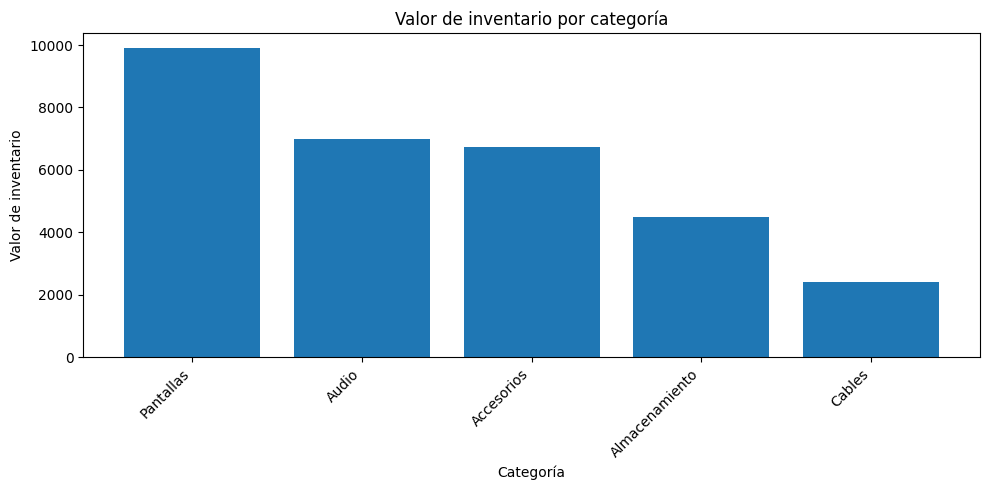

Gráfica guardada:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\graficas\valor_inventario_por_categoria_api.png


WindowsPath('dia_16_reportes_api/graficas/valor_inventario_por_categoria_api.png')

In [38]:
graficar_valor_inventario_por_categoria(valor_inventario_df)

In [41]:
def generar_todos_los_reportes(api):
    """
    Consume la API, genera reportes, exporta CSV y crea gráficas.
    """
    productos = pd.DataFrame(api.listar_productos(solo_activos=False))
    clientes = pd.DataFrame(api.listar_clientes(solo_activos=False))
    ventas = pd.DataFrame(api.listar_ventas())

    ventas_detalle = construir_reporte_ventas_detalle(api, ventas)

    if not productos.empty:
        productos["precio"] = pd.to_numeric(productos["precio"], errors="coerce")
        productos["stock"] = pd.to_numeric(productos["stock"], errors="coerce")
        productos["activo"] = pd.to_numeric(productos["activo"], errors="coerce")

    if not clientes.empty:
        clientes["activo"] = pd.to_numeric(clientes["activo"], errors="coerce")

    if not ventas.empty:
        ventas["total"] = pd.to_numeric(ventas["total"], errors="coerce")

    if not ventas_detalle.empty:
        ventas_detalle["cantidad"] = pd.to_numeric(ventas_detalle["cantidad"], errors="coerce")
        ventas_detalle["subtotal"] = pd.to_numeric(ventas_detalle["subtotal"], errors="coerce")

    ventas_por_producto = generar_ventas_por_producto(ventas_detalle)
    ventas_por_cliente = generar_ventas_por_cliente(ventas)
    productos_bajo_stock = generar_productos_bajo_stock(productos)
    valor_inventario = generar_valor_inventario(productos)
    resumen_general = generar_resumen_general(productos, clientes, ventas)

    exportar_csv(productos, "productos_api.csv")
    exportar_csv(clientes, "clientes_api.csv")
    exportar_csv(ventas, "ventas_api.csv")
    exportar_csv(ventas_detalle, "ventas_detalle_api.csv")
    exportar_csv(ventas_por_producto, "ventas_por_producto_api.csv")
    exportar_csv(ventas_por_cliente, "ventas_por_cliente_api.csv")
    exportar_csv(productos_bajo_stock, "productos_bajo_stock_api.csv")
    exportar_csv(valor_inventario, "valor_inventario_api.csv")
    exportar_csv(resumen_general, "resumen_general_api.csv")

    graficar_ventas_por_producto(ventas_por_producto)
    graficar_ventas_por_cliente(ventas_por_cliente)
    graficar_productos_bajo_stock(productos_bajo_stock)
    graficar_valor_inventario_por_categoria(valor_inventario)

    return {
        "productos": productos,
        "clientes": clientes,
        "ventas": ventas,
        "ventas_detalle": ventas_detalle,
        "ventas_por_producto": ventas_por_producto,
        "ventas_por_cliente": ventas_por_cliente,
        "productos_bajo_stock": productos_bajo_stock,
        "valor_inventario": valor_inventario,
        "resumen_general": resumen_general
    }

CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\productos_api.csv
CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\clientes_api.csv
CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\ventas_api.csv
CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\ventas_detalle_api.csv
CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\ventas_por_producto_api.csv
CSV exportado:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\csv\ventas_por_cliente_api.csv
CSV exportado:
C:\Users\alumn\On

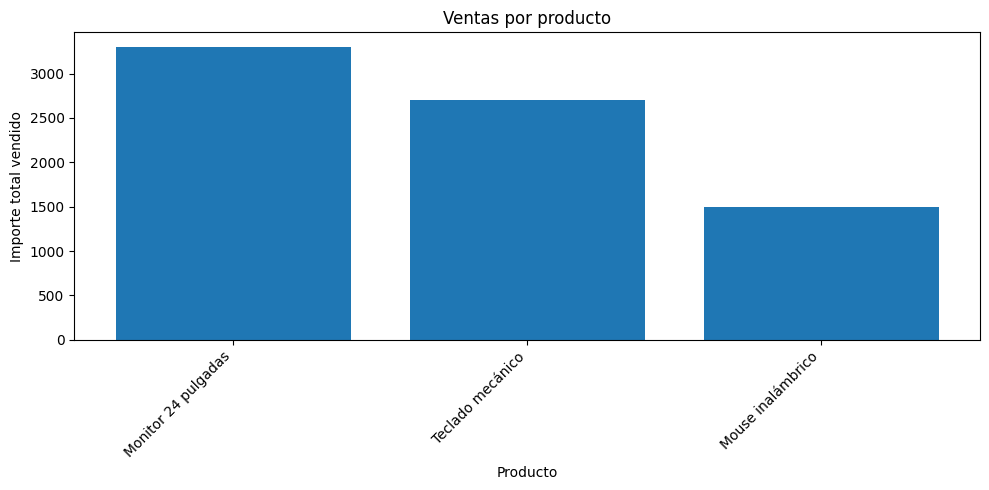

Gráfica guardada:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\graficas\ventas_por_producto_api.png


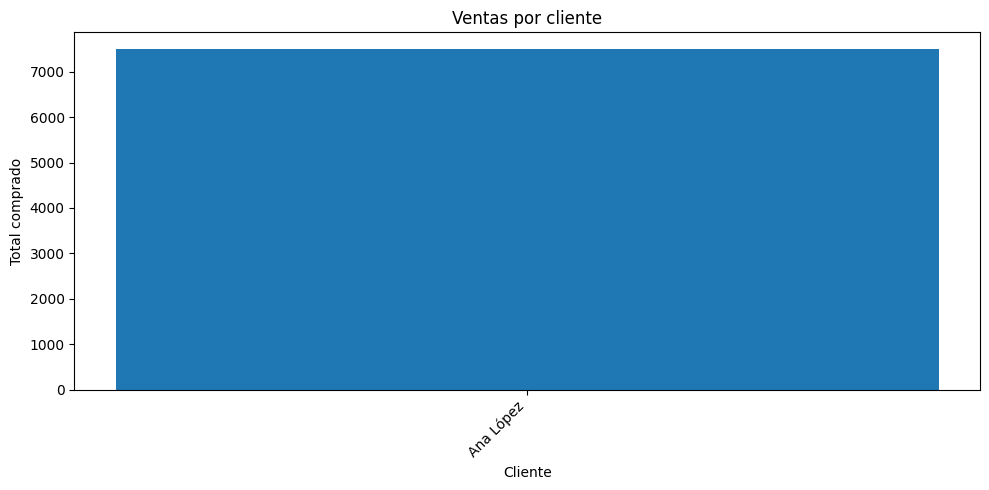

Gráfica guardada:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\graficas\ventas_por_cliente_api.png


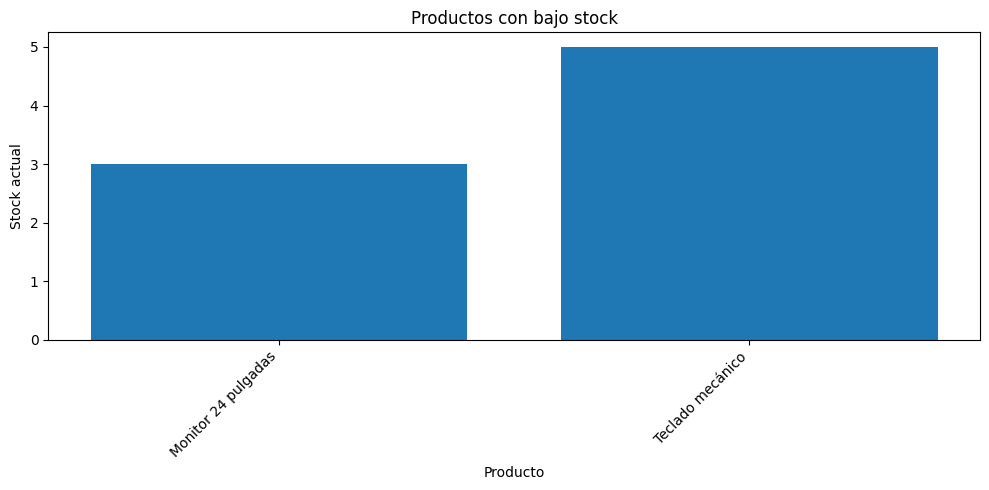

Gráfica guardada:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\graficas\productos_bajo_stock_api.png


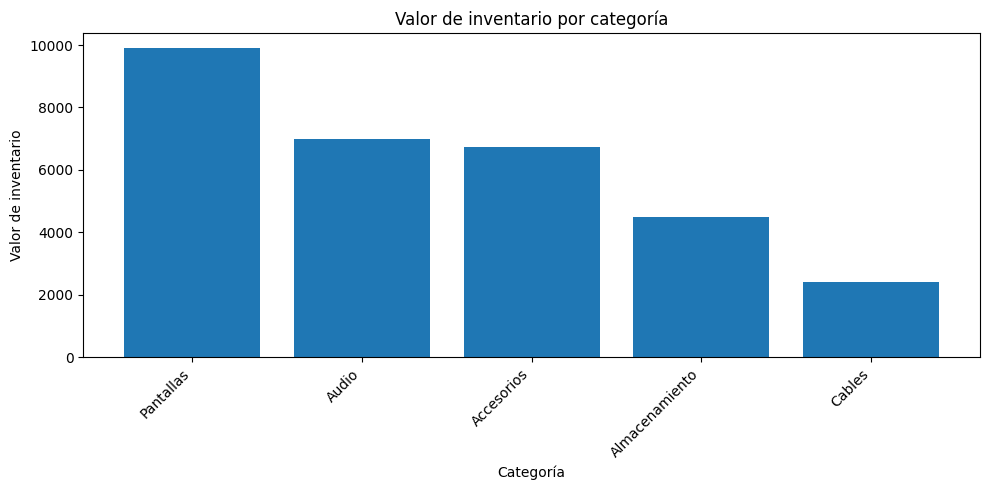

Gráfica guardada:
C:\Users\alumn\OneDrive\Escritorio\Cursos 2026-02\Persistencia de datos con python\Códigos\notebooks\dia_16_reportes_api\graficas\valor_inventario_por_categoria_api.png


In [42]:
reportes = generar_todos_los_reportes(api)